# 03 — Historical day-matching benchmark

A deliberately *simple*, non-parametric baseline for the generative models
trained in 03a (diffusion), 03b (rectified flow), 03c (CVAE).

For every query condition $(c_{\text{discrete}}, c_{\text{continuous}})$ the
baseline retrieves real training profiles that

1. exactly match the discrete cell $(\text{cluster\_id}, \text{day\_type}, \text{season})$, and
2. lie within a tolerance of the query in the **3-channel** continuous space
   $(\text{temp\_normed}, \widetilde{\log\overline{x}}, \widetilde{\log s_x})$,

then draws one profile uniformly at random from the matched pool.

This benchmark has **no learnable parameters**: it memorises the training set
and retrieves at inference time. It is competitive on small datasets, lacks
inductive bias, and degenerates for unseen condition cells — exactly the
properties we want the generative models to beat.

Inputs are kept **fully consistent** with the locked design in notebook 02:
* `data/clusters.csv`        — `(meter_id, date, cluster_id)`
* `data/daily_covariates.csv` — `(meter_id, date, temp_normed, log_mean_z, log_std_z)`

The same train/val split (seed=42, val_fraction=0.15) used by 03a/03b/03c
applies here so the metrics are directly comparable.


In [8]:
import sys, os, pathlib, json
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader  import load_rolle_data, compute_temp_stats, normalize_temp
from src.data.dataset import make_daily_instances, train_val_split_instances
from src.runtime_paths import DATA_DIR, OUTPUT_DIR

sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi'] = 110
RANDOM_SEED  = 42
VAL_FRACTION = 0.15


## 1. Load data and the locked 6-channel conditioning vector

Combine the power dataset with the two CSVs produced by notebook 02 to obtain
exactly the discrete + extended-continuous conditioning that the 03a/03b/03c
training notebooks will consume.


In [9]:
power_df, temp_daily = load_rolle_data(DATA_DIR)
temp_stats  = compute_temp_stats(temp_daily)
temp_normed = normalize_temp(temp_daily, temp_stats)

# (a) cluster labels saved by notebook 02 §9
df_cl = pd.read_csv(pathlib.Path(DATA_DIR) / 'clusters.csv')
cl_lookup = {(int(r.meter_id), r.date): int(r.cluster_id) for _, r in df_cl.iterrows()}

# (b) extended continuous covariates saved by notebook 02 §9
df_cov   = pd.read_csv(pathlib.Path(DATA_DIR) / 'daily_covariates.csv')
cov_keys = list(zip(df_cov.meter_id.astype(int), df_cov.date.astype(str)))
cov_lookup = {k: (float(t), float(m), float(s))
              for k, t, m, s in zip(cov_keys, df_cov.temp_normed,
                                    df_cov.log_mean_z, df_cov.log_std_z)}

# (c) scale stats saved by notebook 02 §9 — needed to denormalise back to W.
scale_stats = json.loads((pathlib.Path(DATA_DIR) / 'scale_stats.json').read_text())

# Build instances with discrete cluster_id baked in. The c_cont returned here
# is the (legacy) 1-channel temp_normed; we override it below with the 3-channel
# extended vector.
xs, c_disc, c_cont1, dates, meter_ids = make_daily_instances(
    power_df, temp_normed, cluster_labels=cl_lookup
)

# Per-instance shape normalisation: the baseline (and every learned model)
# is trained on `xs_norm` — pure shape, mean 0 std 1 per row. The raw
# log_mean / log_std are kept so we can invert the normalisation and
# report metrics in Watts at the end of this notebook.
from src.data.dataset import shape_normalize
xs_norm, log_mean, log_std = shape_normalize(xs)

# Align extended continuous channels to instance order.
c_cont_ext = np.zeros((len(xs), 3), dtype=np.float32)
missing = 0
for i, (m, d) in enumerate(zip(meter_ids, dates)):
    key = (int(m), str(d))
    if key in cov_lookup:
        c_cont_ext[i] = cov_lookup[key]
    else:
        # Fall back to the legacy 1-channel value; log_mean / log_std stay 0.
        c_cont_ext[i, 0] = c_cont1[i, 0]
        missing += 1
assert missing == 0, f'{missing} instances missing covariate rows'

N_METERS   = int(meter_ids.max()) + 1
N_CLUSTERS = int(c_disc[:, 0].max()) + 1
print(f'Instances        : {len(xs):,}')
print(f'c_discrete shape : {c_disc.shape}  (cluster_id, day_type, season)')
print(f'c_continuous     : {c_cont_ext.shape}  (temp_normed, log_mean_z, log_std_z)')
print(f'xs_norm          : {xs_norm.shape}  '
      f'per-row mean={xs_norm.mean(1).mean():+.2e}  std={xs_norm.std(1).mean():.3f}')
print(f'N_CLUSTERS       : {N_CLUSTERS}   N_METERS: {N_METERS}')


Instances        : 8,928
c_discrete shape : (8928, 3)  (cluster_id, day_type, season)
c_continuous     : (8928, 3)  (temp_normed, log_mean_z, log_std_z)
xs_norm          : (8928, 24)  per-row mean=-3.42e-09  std=1.000
N_CLUSTERS       : 5   N_METERS: 24


## 2. Train / val split (identical to 03a / 03b / 03c)

In [10]:
from src.data.dataset import split_mask_by_meter

# Split on the normalised profiles (this is what every model is trained on).
x_tr, cd_tr, cc_tr, mid_tr, x_val, cd_val, cc_val, mid_val = train_val_split_instances(
    xs_norm, c_disc, c_cont_ext, meter_ids,
    n_meters=N_METERS, val_fraction=VAL_FRACTION, seed=RANDOM_SEED,
)

# Reproduce the *exact same* mask to split the per-instance log_mean / log_std,
# which we need at evaluation time to denormalise generated profiles back to W.
val_mask = split_mask_by_meter(meter_ids, n_meters=N_METERS,
                               val_fraction=VAL_FRACTION, seed=RANDOM_SEED)
log_mean_tr, log_std_tr = log_mean[~val_mask], log_std[~val_mask]
log_mean_val, log_std_val = log_mean[val_mask], log_std[val_mask]

print(f'Train: {len(x_tr):,}   Val: {len(x_val):,}')
print(f'cc_tr.shape={cc_tr.shape}  cc_val.shape={cc_val.shape}')
print(f'log_mean_val: mean={log_mean_val.mean():.3f}  std={log_mean_val.std():.3f}')


Train: 7,440   Val: 1,488
cc_tr.shape=(7440, 3)  cc_val.shape=(1488, 3)
log_mean_val: mean=3.419  std=0.453


## 3. Fit the historical day-matching baseline

`HistoricalBaseline.sample(c_disc_q, c_cont_q)` performs adaptive nearest-neighbour
retrieval: discrete-exact match, then progressively widened Euclidean ball in
continuous-space. Because the 3 continuous channels are already global z-scored,
plain Euclidean distance is well-scaled.

The baseline is fitted on **per-instance shape-normalised** profiles (`x_tr`),
matching what the learned models in 03a/03b/03c train on. Generated samples
are therefore also in normalised space; we map them back to Watts in §4
using each query's `(log_mean_z, log_std_z)` channels before computing kW
metrics.

The `tol` argument is the **initial** radius (in z-score units). The pool size
is automatically grown by doubling `tol` up to 3 times to ensure at least
`min_pool` candidates.


In [11]:
from src.models.historical_baseline import HistoricalBaseline

baseline = HistoricalBaseline(min_pool=5, seed=RANDOM_SEED)
baseline.fit(xs=x_tr, c_discrete=cd_tr, c_continuous=cc_tr,
             dates=None, meter_ids=mid_tr)
print(f'Baseline fitted on {len(x_tr):,} training profiles.')
print(f'  conditioning channels: discrete={cd_tr.shape[1]}  continuous={cc_tr.shape[1]}')


Baseline fitted on 7,440 training profiles.
  conditioning channels: discrete=3  continuous=3


## 4. Generate one sample per validation instance

The benchmark's `generate(c_batch, key, c_continuous_batch)` returns one
retrieved profile per query condition — directly comparable to a single
draw from a generative model conditioned on the same vector.


In [12]:
from src.data.dataset import shape_denormalize
from src.data.loader  import invert_scale_z

# 1. Generate normalised samples from the baseline, one per val condition.
x_val_gen_norm = baseline.generate(
    c_batch=cd_val, key=RANDOM_SEED, c_continuous_batch=cc_val, temp_tol=0.5,
)
print(f'Generated (normalised) shape: {x_val_gen_norm.shape}  '
      f'(expected {x_val.shape})')

# 2. Map both real and generated profiles back to Watts using the per-instance
#    scale conditioning. For the *real* val set we use the directly-computed
#    `log_mean_val` / `log_std_val`; for the *generated* set we recover the
#    same quantities by inverting the global z-score of cc_val[:, 1:3]. Both
#    routes should agree numerically because cc_val was built from those very
#    log_mean / log_std arrays in notebook 02.
x_val_real_W = shape_denormalize(x_val, log_mean_val, log_std_val)
log_mean_q, log_std_q = invert_scale_z(cc_val[:, 1], cc_val[:, 2], scale_stats)
x_val_gen_W  = shape_denormalize(x_val_gen_norm, log_mean_q, log_std_q)

# 3. Point metrics in Watts (the meaningful unit for reporting).
abs_err = np.abs(x_val_gen_W - x_val_real_W)
mae     = float(abs_err.mean())
rmse    = float(np.sqrt(((x_val_gen_W - x_val_real_W) ** 2).mean()))
energy_real = x_val_real_W.sum(axis=1)
energy_gen  = x_val_gen_W.sum(axis=1)
energy_mape = float(np.abs(energy_gen - energy_real).sum() / max(1e-9, energy_real.sum()))

print(f'\nVal-set point metrics (single sample per instance, Watts):')
print(f'  MAE              = {mae:.3f} W')
print(f'  RMSE             = {rmse:.3f} W')
print(f'  daily-energy MAPE = {energy_mape*100:.2f} %')

# Keep a normalised-space view too, for sanity comparison with model losses.
mae_norm  = float(np.abs(x_val_gen_norm - x_val).mean())
rmse_norm = float(np.sqrt(((x_val_gen_norm - x_val) ** 2).mean()))
print(f'\nFor reference, in normalised (shape) units:')
print(f'  MAE_norm  = {mae_norm:.3f}   RMSE_norm = {rmse_norm:.3f}')


Generated (normalised) shape: (1488, 24)  (expected (1488, 24))

Val-set point metrics (single sample per instance, Watts):
  MAE              = 3.788 W
  RMSE             = 5.066 W
  daily-energy MAPE = 0.00 %

For reference, in normalised (shape) units:
  MAE_norm  = 0.571   RMSE_norm = 0.748


## 5. Sanity-check panel — all clusters × 4 day/season conditions

Grid: rows = clusters (0–4) · columns = (weekday/weekend) × (winter/summer).
Each panel shows a few validation instances paired with the benchmark profile
generated for the **same** continuous condition.

* **Same colour** → same meter (real vs benchmark come from the same query)
* **Solid line** → real profile from that meter on that day
* **Dashed line** → profile retrieved by the benchmark for that meter's condition

Mirrors §7 of 03a/03b/03c for direct cross-model comparison.

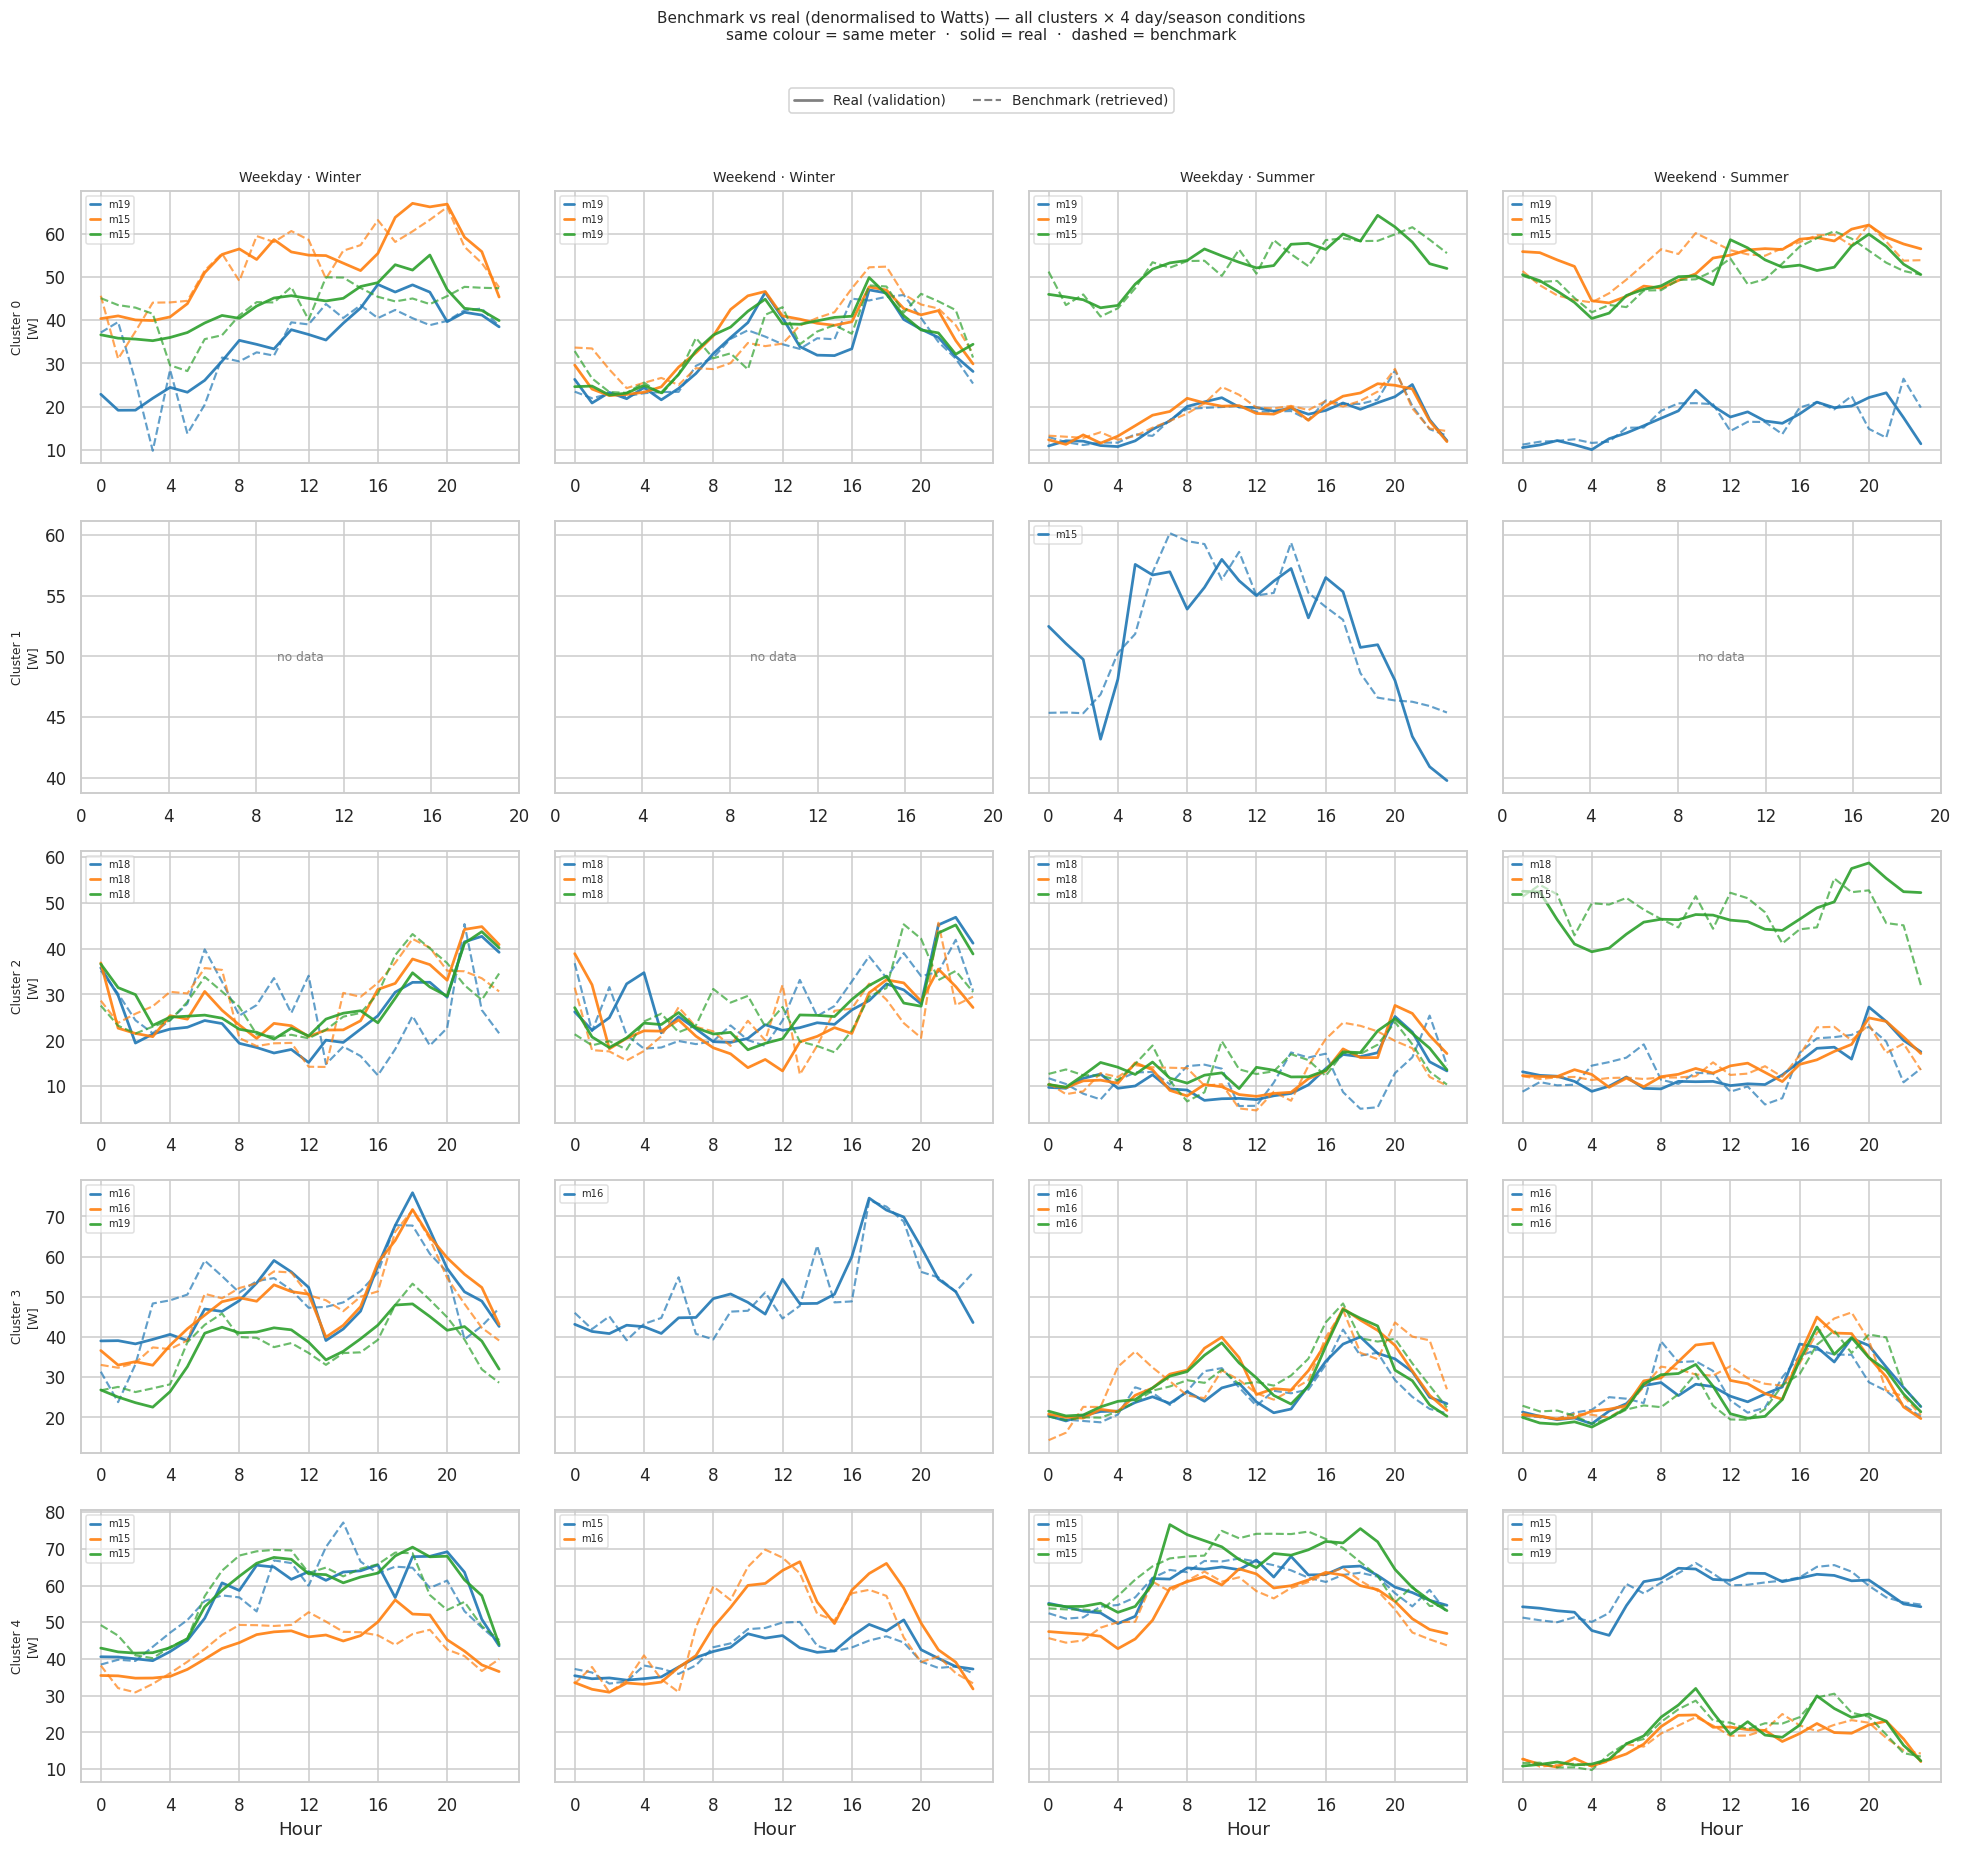

In [13]:
from matplotlib.lines import Line2D

hours    = np.arange(24)
n_sample = 3   # meters shown per panel (keeps the grid readable)
rng      = np.random.default_rng(RANDOM_SEED)

day_season_specs = [
    (0, 0, 'Weekday · Winter'),
    (1, 0, 'Weekend · Winter'),
    (0, 2, 'Weekday · Summer'),
    (1, 2, 'Weekend · Summer'),
]

n_rows = N_CLUSTERS
n_cols = len(day_season_specs)

# One colour per meter slot; same colour links the real line to its benchmark pair.
pair_colors = plt.cm.tab10(np.arange(n_sample))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4.5 * n_cols, 3.2 * n_rows),
    sharey='row',   # share y scale within each cluster row
)

for row, cid in enumerate(range(N_CLUSTERS)):
    for col, (dt, season, cond_label) in enumerate(day_season_specs):
        ax = axes[row, col]
        mask = (cd_val[:, 0] == cid) & (cd_val[:, 1] == dt) & (cd_val[:, 2] == season)

        if row == 0:
            ax.set_title(cond_label, fontsize=9)
        if col == 0:
            ax.set_ylabel(f'Cluster {cid}\n[W]', fontsize=8)
        ax.set_xticks(hours[::4])
        if row == n_rows - 1:
            ax.set_xlabel('Hour')

        if not mask.any():
            ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                    ha='center', va='center', fontsize=8, color='grey')
            continue

        # Pick n_sample real validation instances from this condition cell.
        idx    = np.where(mask)[0]
        chosen = rng.choice(idx, size=min(n_sample, len(idx)), replace=False)

        # Generate one benchmark profile per chosen instance using its exact
        # continuous condition — this gives a direct paired comparison.
        cc_q = cc_val[chosen].astype(np.float32)
        cd_q = np.tile(np.array([cid, dt, season], dtype=np.int32), (len(chosen), 1))
        bench_samples_norm = baseline.generate(
            c_batch=cd_q,
            key=int(rng.integers(1 << 30)),
            c_continuous_batch=cc_q,
            temp_tol=0.5,
        )

        # Denormalise both real and benchmark to Watts so the plot has
        # interpretable units. Per-instance scales come from the val arrays
        # (real) and from the queried cc rows (generated) — they agree by
        # construction here, since cc_val rows correspond 1:1 to val instances.
        bench_lm, bench_ls = invert_scale_z(cc_q[:, 1], cc_q[:, 2], scale_stats)
        bench_W = shape_denormalize(bench_samples_norm, bench_lm, bench_ls)
        real_W  = shape_denormalize(x_val[chosen],
                                    log_mean_val[chosen], log_std_val[chosen])

        for k, ci in enumerate(chosen):
            mid   = int(mid_val[ci])
            color = pair_colors[k]
            ax.plot(hours, real_W[k],
                    color=color, linewidth=1.8, linestyle='-', alpha=0.9,
                    label=f'm{mid}')
            ax.plot(hours, bench_W[k],
                    color=color, linewidth=1.4, linestyle='--', alpha=0.7,
                    label='_nolegend_')

        # Per-panel legend: meter ID colour key only (style explained globally).
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, fontsize=6.5, loc='upper left',
                  framealpha=0.6, ncol=1, handlelength=1.0)

# Shared figure-level legend: line-style convention.
style_legend = [
    Line2D([0], [0], color='grey', linewidth=1.8, linestyle='-',
           label='Real (validation)'),
    Line2D([0], [0], color='grey', linewidth=1.4, linestyle='--',
           label='Benchmark (retrieved)'),
]
fig.legend(handles=style_legend, loc='upper center', ncol=2,
           fontsize=9, bbox_to_anchor=(0.5, 1.01), framealpha=0.85)

plt.suptitle(
    'Benchmark vs real (denormalised to Watts) — all clusters × 4 day/season conditions\n'
    'same colour = same meter  ·  solid = real  ·  dashed = benchmark',
    fontsize=10, y=1.05,
)
plt.tight_layout()
plt.show()


## 6. Save summary

Writes the benchmark scorecard to `output/03_benchmark/results/summary.json`
in a layout compatible with the trained-model summaries used by 04/05.


In [14]:
summary_dir = pathlib.Path(OUTPUT_DIR) / '03_benchmark' / 'results'
summary_dir.mkdir(parents=True, exist_ok=True)
summary_path = summary_dir / 'summary.json'

summary = {
    'model'           : 'HistoricalBaseline',
    'parametric'      : False,
    'train_instances' : int(len(x_tr)),
    'val_instances'   : int(len(x_val)),
    'n_clusters'      : int(N_CLUSTERS),
    'c_discrete'      : ['cluster_id', 'day_type', 'season'],
    'c_continuous'    : ['temp_normed', 'log_mean_z', 'log_std_z'],
    'temp_tol'        : 0.5,
    'min_pool'        : 5,
    'normalisation'   : 'per-instance shape z-score (xs trained on xs_norm)',
    'metrics_units'   : 'Watts',
    'metrics'         : {
        'mae_W'              : float(mae),
        'rmse_W'             : float(rmse),
        'daily_energy_mape'  : float(energy_mape),
        'mae_norm'           : float(mae_norm),
        'rmse_norm'          : float(rmse_norm),
    },
    'random_seed'     : RANDOM_SEED,
    'val_fraction'    : VAL_FRACTION,
}
summary_path.write_text(json.dumps(summary, indent=2))
print(f'Saved → {summary_path}')
print(json.dumps(summary, indent=2))


Saved → /home/nicola/Desktop/Supsi/tesina/output/03_benchmark/results/summary.json
{
  "model": "HistoricalBaseline",
  "parametric": false,
  "train_instances": 7440,
  "val_instances": 1488,
  "n_clusters": 5,
  "c_discrete": [
    "cluster_id",
    "day_type",
    "season"
  ],
  "c_continuous": [
    "temp_normed",
    "log_mean_z",
    "log_std_z"
  ],
  "temp_tol": 0.5,
  "min_pool": 5,
  "normalisation": "per-instance shape z-score (xs trained on xs_norm)",
  "metrics_units": "Watts",
  "metrics": {
    "mae_W": 3.787580966949463,
    "rmse_W": 5.066189765930176,
    "daily_energy_mape": 6.259760709781403e-08,
    "mae_norm": 0.5706555843353271,
    "rmse_norm": 0.7483280897140503
  },
  "random_seed": 42,
  "val_fraction": 0.15
}
